In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler

In [2]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_BACKTESTS = PROJECT_ROOT / "data" / "backtests"

DATA_BACKTESTS.mkdir(parents=True, exist_ok=True)

In [3]:
features = pd.read_parquet(DATA_PROCESSED / "features.parquet")
returns = pd.read_parquet(DATA_PROCESSED / "returns.parquet")

features.index = pd.to_datetime(features.index)
returns.index = pd.to_datetime(returns.index)

features.shape, returns.shape

((2396, 180), (2515, 30))

In [4]:
WINDOW = 60
HORIZON = 10

D_MODEL = 32
N_HEADS = 4

TEMPORAL_LAYERS = 1
STOCK_LAYERS = 1

D_FF = 64
DROPOUT = 0.1

BATCH_SIZE = 64
N_EPOCHS = 50
PATIENCE = 8

TRAIN_RATIO = 0.7
VAL_RATIO_WITHIN_TRAIN = 0.8

REBALANCE_EVERY = 10
LONG_Q = 0.8
SHORT_Q = 0.2
TRANSACTION_COST = 0.001

SEED = 42

In [5]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

In [6]:
tickers = features.columns.get_level_values("ticker").unique().tolist()
feature_names = features.columns.get_level_values("feature").unique().tolist()

n_stocks = len(tickers)
n_features = len(feature_names)

n_stocks, n_features, feature_names[:]

(30,
 6,
 ['momentum_120',
  'momentum_20',
  'momentum_60',
  'return_1d',
  'volatility_20',
  'volatility_60'])

In [7]:
feature_tensor_list = []

for ticker in tickers:
    df_t = features[ticker][feature_names].copy()
    feature_tensor_list.append(df_t.values)

# list: n_stocks darab (n_dates, n_features)
# stack után: (n_dates, n_stocks, n_features)

feature_array = np.stack(feature_tensor_list, axis=1)

dates = features.index.to_numpy()

feature_array.shape

(2396, 30, 6)

In [8]:
future_returns = pd.DataFrame(
    0.0,
    index=returns.index,
    columns=returns.columns
)

for h in range(1, HORIZON + 1):
    future_returns += returns.shift(-h)

future_returns = future_returns.reindex(features.index)

In [9]:
target_list = []

for ticker in tickers:
    target_list.append(future_returns[ticker].values)

# (n_dates, n_stocks)
target_array = np.stack(target_list, axis=1)

target_array.shape

(2396, 30)

In [10]:
X_list = []
y_list = []
sample_dates = []

for end_idx in range(WINDOW, len(dates)):
    start_idx = end_idx - WINDOW

    X_window = feature_array[start_idx:end_idx]  # (window, stocks, features)
    y_target = target_array[end_idx]            # (stocks,)

    if np.isnan(X_window).any():
        continue

    if np.isnan(y_target).any():
        continue

    # átrendezés: (stocks, window, features)
    X_window = np.transpose(X_window, (1, 0, 2))

    X_list.append(X_window)
    y_list.append(y_target)
    sample_dates.append(dates[end_idx])

X_market = np.stack(X_list, axis=0).astype(np.float32)
y_market = np.stack(y_list, axis=0).astype(np.float32)
sample_dates = pd.to_datetime(np.array(sample_dates))

X_market.shape, y_market.shape, sample_dates.shape

((2326, 30, 60, 6), (2326, 30), (2326,))

In [11]:
all_sample_dates = np.sort(sample_dates.unique())

split_date = all_sample_dates[int(TRAIN_RATIO * len(all_sample_dates))]

train_full_mask = sample_dates < split_date
test_mask = sample_dates >= split_date

train_dates = np.sort(sample_dates[train_full_mask].unique())

val_start = train_dates[int(VAL_RATIO_WITHIN_TRAIN * len(train_dates))]

train_mask = train_full_mask & (sample_dates < val_start)
val_mask = train_full_mask & (sample_dates >= val_start)

split_date, val_start

(np.datetime64('2022-03-09T00:00:00.000000000'),
 np.datetime64('2020-11-19T00:00:00.000000000'))

In [12]:
feature_mean = X_market[train_mask].mean(axis=(0, 1, 2), keepdims=True)
feature_std = X_market[train_mask].std(axis=(0, 1, 2), keepdims=True)

X_scaled = (X_market - feature_mean) / (feature_std + 1e-8)

In [13]:
y_mean = y_market[train_mask].mean()
y_std = y_market[train_mask].std()

y_scaled = (y_market - y_mean) / (y_std + 1e-8)

X_scaled.shape, y_scaled.shape

((2326, 30, 60, 6), (2326, 30))

In [14]:
class MarketWindowDataset(Dataset):
    def __init__(self, X, y, dates):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.dates = dates

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [15]:
train_dataset = MarketWindowDataset(
    X_scaled[train_mask],
    y_scaled[train_mask],
    sample_dates[train_mask]
)

val_dataset = MarketWindowDataset(
    X_scaled[val_mask],
    y_scaled[val_mask],
    sample_dates[val_mask]
)

test_dataset = MarketWindowDataset(
    X_scaled[test_mask],
    y_scaled[test_mask],
    sample_dates[test_mask]
)

In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [17]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(
            0,
            max_len,
            dtype=torch.float32
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

In [18]:
class TemporalStockAttentionModel(nn.Module):
    def __init__(
        self,
        n_features,
        n_stocks,
        window,
        d_model=32,
        n_heads=4,
        temporal_layers=1,
        stock_layers=1,
        d_ff=64,
        dropout=0.1,
    ):
        super().__init__()

        self.n_features = n_features
        self.n_stocks = n_stocks
        self.window = window
        self.d_model = d_model

        self.input_projection = nn.Linear(n_features, d_model)

        self.positional_encoding = PositionalEncoding(
            d_model=d_model,
            max_len=window
        )

        temporal_encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.temporal_encoder = nn.TransformerEncoder(
            temporal_encoder_layer,
            num_layers=temporal_layers
        )

        stock_encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.stock_encoder = nn.TransformerEncoder(
            stock_encoder_layer,
            num_layers=stock_layers
        )

        self.prediction_head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        """
        x shape:
            (batch, n_stocks, window, n_features)

        output:
            y_pred shape (batch, n_stocks)
        """

        B, N, T, F = x.shape

        # stockokat batch dimenzióba hajtjuk:
        # (B*N, T, F)
        x = x.view(B * N, T, F)

        x = self.input_projection(x)       # (B*N, T, d_model)
        x = self.positional_encoding(x)    # temporal PE
        x = self.temporal_encoder(x)       # temporal attention

        # temporal pooling: részvényenként egy embedding
        stock_emb = x.mean(dim=1)          # (B*N, d_model)

        # vissza: (B, N, d_model)
        stock_emb = stock_emb.view(B, N, self.d_model)

        # stock-to-stock attention
        stock_context = self.stock_encoder(stock_emb)

        y_pred = self.prediction_head(stock_context).squeeze(-1)

        return y_pred

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TemporalStockAttentionModel(
    n_features=n_features,
    n_stocks=n_stocks,
    window=WINDOW,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    temporal_layers=TEMPORAL_LAYERS,
    stock_layers=STOCK_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

loss_fn = nn.MSELoss()

model

TemporalStockAttentionModel(
  (input_projection): Linear(in_features=6, out_features=32, bias=True)
  (positional_encoding): PositionalEncoding()
  (temporal_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (stock_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (

In [20]:
best_val_corr = -np.inf
best_state = None
best_epoch = None
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_corr": [],
}

In [21]:
for epoch in range(N_EPOCHS):
    model.train()

    train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        y_pred = model(xb)

        loss = loss_fn(y_pred, yb)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        train_loss += loss.item() * len(xb)

    train_loss /= len(train_dataset)

    model.eval()

    val_loss = 0.0
    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            y_pred = model(xb)

            loss = loss_fn(y_pred, yb)

            val_loss += loss.item() * len(xb)

            y_true_all.append(yb.cpu().numpy().ravel())
            y_pred_all.append(y_pred.cpu().numpy().ravel())

    val_loss /= len(val_dataset)

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)

    val_corr = np.corrcoef(y_true_all, y_pred_all)[0, 1]

    if np.isnan(val_corr):
        val_corr = -np.inf

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_corr"].append(val_corr)

    if val_corr > best_val_corr:
        best_val_corr = val_corr
        best_epoch = epoch
        best_state = {
            k: v.cpu().clone()
            for k, v in model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch % 5 == 0 or epoch == N_EPOCHS - 1:
        print(
            f"Epoch {epoch:03d} | "
            f"train loss {train_loss:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val corr {val_corr:.4f} | "
            f"best {best_val_corr:.4f}"
        )

    if epochs_without_improvement >= PATIENCE:
        print(
            f"Early stopping at epoch {epoch}, "
            f"best epoch {best_epoch}, "
            f"best val corr {best_val_corr:.4f}"
        )
        break

model.load_state_dict(best_state)

Epoch 000 | train loss 0.9924 | val loss 0.9783 | val corr 0.0010 | best 0.0010
Epoch 005 | train loss 0.9368 | val loss 0.9831 | val corr -0.0007 | best 0.0010
Epoch 010 | train loss 0.8716 | val loss 1.0073 | val corr 0.0717 | best 0.0717
Epoch 015 | train loss 0.7808 | val loss 0.9741 | val corr 0.1691 | best 0.1691
Epoch 020 | train loss 0.7492 | val loss 0.9617 | val corr 0.2033 | best 0.2033
Epoch 025 | train loss 0.7219 | val loss 1.0199 | val corr 0.1762 | best 0.2033
Early stopping at epoch 28, best epoch 20, best val corr 0.2033


<All keys matched successfully>

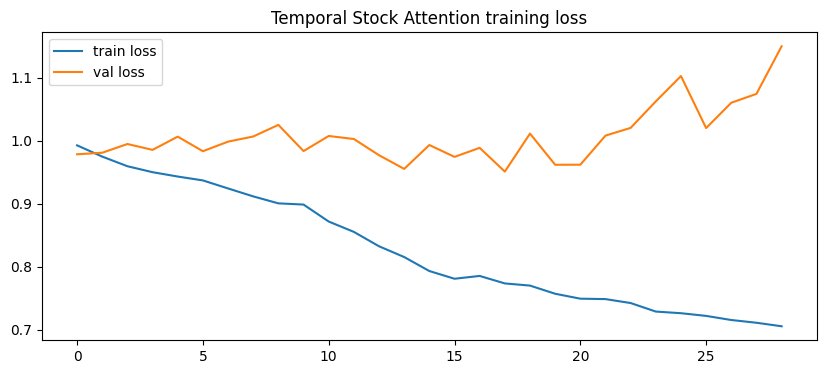

In [22]:
plt.figure(figsize=(10, 4))

plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")

plt.legend()
plt.title("Temporal Stock Attention training loss")
plt.show()

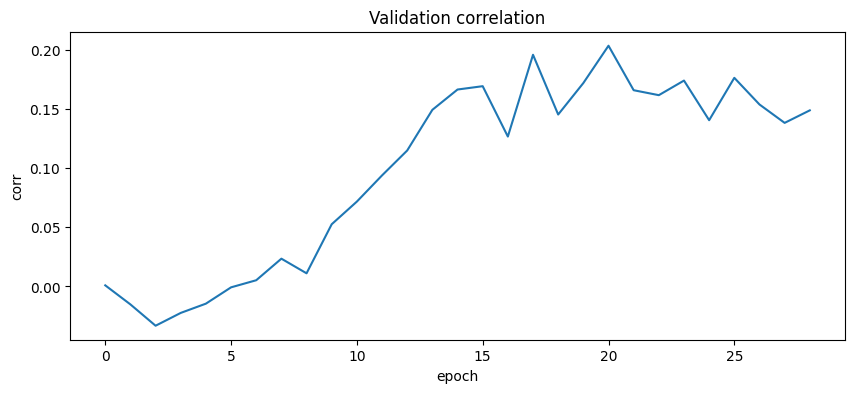

In [23]:
plt.figure(figsize=(10, 4))

plt.plot(history["val_corr"])

plt.title("Validation correlation")
plt.ylabel("corr")
plt.xlabel("epoch")
plt.show()

In [24]:
model.eval()

test_preds = []
test_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)

        y_pred = model(xb)

        test_preds.append(y_pred.cpu().numpy())
        test_targets.append(yb.numpy())

test_preds = np.concatenate(test_preds, axis=0)
test_targets = np.concatenate(test_targets, axis=0)

# unscale
test_preds_unscaled = test_preds * y_std + y_mean
test_targets_unscaled = test_targets * y_std + y_mean

test_preds_unscaled.shape, test_targets_unscaled.shape

((698, 30), (698, 30))

In [25]:
test_corr = np.corrcoef(
    test_targets_unscaled.ravel(),
    test_preds_unscaled.ravel()
)[0, 1]

test_corr

np.float64(0.0933905229141557)

In [26]:
test_dates = sample_dates[test_mask]

score_df = pd.DataFrame(
    test_preds_unscaled,
    index=test_dates,
    columns=tickers
)

score_df.head()

,AAPL,ABBV,ADBE,AMD,AMZN,AVGO,BAC,COST,CRM,CSCO,...,NFLX,NVDA,ORCL,PEP,PG,TSLA,UNH,V,WMT,XOM
2022-03-09,0.024348,0.020605,0.075532,0.055096,0.041485,0.023839,0.023397,0.008429,0.078654,0.016627,...,0.073863,0.073607,0.031048,0.011569,0.016490,0.056358,0.016040,0.033487,0.012568,0.024109
2022-03-10,0.028104,0.022828,0.075958,0.062341,0.045796,0.029795,0.027790,0.011945,0.078298,0.019956,...,0.080203,0.083027,0.035508,0.014453,0.020075,0.064545,0.019705,0.037155,0.015158,0.031850
2022-03-11,0.031029,0.023880,0.074899,0.062904,0.044452,0.032721,0.027669,0.013743,0.076930,0.022566,...,0.085613,0.084208,0.035558,0.016217,0.022783,0.064180,0.021059,0.038364,0.016540,0.035526
2022-03-14,0.031142,0.023091,0.073558,0.057190,0.041424,0.030827,0.023510,0.013247,0.071746,0.021776,...,0.091506,0.071934,0.032513,0.015539,0.021975,0.060366,0.019961,0.036847,0.016485,0.036622
2022-03-15,0.030530,0.021597,0.076148,0.050630,0.039227,0.026996,0.018030,0.011425,0.070387,0.020435,...,0.099358,0.058740,0.031449,0.013779,0.019531,0.055797,0.017509,0.034240,0.015338,0.035529


In [27]:
def build_rebalanced_positions_from_scores(
    score_df,
    rebalance_every=10,
    long_q=0.8,
    short_q=0.2
):
    positions = pd.DataFrame(
        0.0,
        index=score_df.index,
        columns=score_df.columns
    )

    current_position = pd.Series(
        0.0,
        index=score_df.columns
    )

    for i, date in enumerate(score_df.index):
        if i % rebalance_every == 0:
            scores = score_df.loc[date].dropna()

            long_threshold = scores.quantile(long_q)
            short_threshold = scores.quantile(short_q)

            new_position = pd.Series(
                0.0,
                index=score_df.columns
            )

            new_position.loc[
                scores[scores >= long_threshold].index
            ] = 1.0

            new_position.loc[
                scores[scores <= short_threshold].index
            ] = -1.0

            current_position = new_position

        positions.loc[date] = current_position

    return positions

In [28]:
def performance_stats(r):
    r = r.dropna()

    total_return = (1 + r).prod() - 1
    ann_return = (1 + total_return) ** (252 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    equity = (1 + r).cumprod()
    drawdown = equity / equity.cummax() - 1

    return pd.Series({
        "total_return": total_return,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": drawdown.min(),
    })

In [30]:
def portfolio_returns_from_positions(
    positions,
    returns,
    transaction_cost=0.0
):
    next_returns = returns.shift(-1)

    common_index = positions.index.intersection(next_returns.index)
    common_cols = positions.columns.intersection(next_returns.columns)

    pos = positions.loc[common_index, common_cols]
    ret = next_returns.loc[common_index, common_cols]

    gross = (pos * ret).mean(axis=1)

    turnover = pos.diff().abs().mean(axis=1).fillna(0.0)

    net = gross - transaction_cost * turnover

    return net, turnover

In [31]:
positions = build_rebalanced_positions_from_scores(
    score_df,
    rebalance_every=REBALANCE_EVERY,
    long_q=LONG_Q,
    short_q=SHORT_Q
)

transformer_returns, transformer_turnover = portfolio_returns_from_positions(
    positions,
    returns,
    transaction_cost=TRANSACTION_COST
)

transformer_returns.name = "temporal_stock_attention"

performance_stats(transformer_returns)

total_return   -0.028180
ann_return     -0.010267
ann_vol         0.056035
sharpe         -0.183222
max_drawdown   -0.132024
dtype: float64

In [32]:
transformer_turnover.mean()

np.float64(0.030181470869149952)

In [33]:
sup_backtest = pd.read_parquet(
    DATA_BACKTESTS / "supervised_vae_backtest_returns.parquet"
)

sup_backtest.index = pd.to_datetime(sup_backtest.index)

comparison = pd.concat(
    [
        sup_backtest["raw_feature_ridge"],
        sup_backtest["supervised_vae_direct"],
        transformer_returns,
    ],
    axis=1
).dropna()

stats = comparison.apply(performance_stats).T

stats.sort_values("sharpe", ascending=False)

,total_return,ann_return,ann_vol,sharpe,max_drawdown
supervised_vae_direct,0.249903,0.083865,0.053503,1.567479,-0.059883
raw_feature_ridge,0.190417,0.064951,0.068585,0.947015,-0.106181
temporal_stock_attention,-0.028180,-0.010267,0.056035,-0.183222,-0.132024


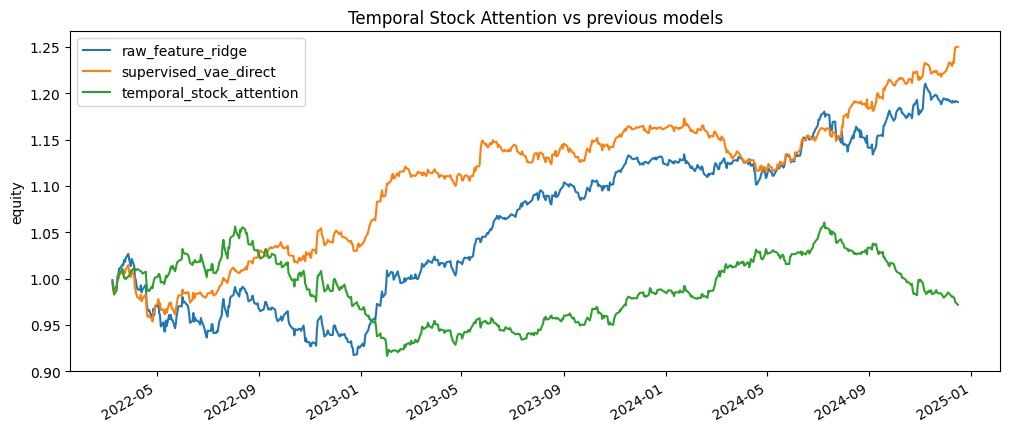

In [34]:
equity = (1 + comparison).cumprod()

equity.plot(
    figsize=(12, 5),
    title="Temporal Stock Attention vs previous models"
)

plt.ylabel("equity")
plt.show()

In [35]:
comparison.to_parquet(
    DATA_BACKTESTS / "temporal_stock_attention_comparison_returns.parquet"
)

stats.to_csv(
    DATA_BACKTESTS / "temporal_stock_attention_comparison_stats.csv"
)

score_df.to_parquet(
    DATA_BACKTESTS / "temporal_stock_attention_scores.parquet"
)

In [36]:
test_corr

np.float64(0.0933905229141557)

In [37]:
score_df.describe()

,AAPL,ABBV,ADBE,AMD,AMZN,AVGO,BAC,COST,CRM,CSCO,...,NFLX,NVDA,ORCL,PEP,PG,TSLA,UNH,V,WMT,XOM
count,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,...,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000
mean,0.011590,0.008851,0.019575,0.022856,0.017227,0.008638,0.013504,0.009617,0.020522,0.012850,...,0.025434,0.021939,0.011857,0.006715,0.007600,0.021719,0.007487,0.009317,0.009505,0.011620
std,0.022293,0.011505,0.032354,0.048753,0.034794,0.031085,0.020536,0.018805,0.032431,0.017480,...,0.042691,0.062702,0.020990,0.010081,0.009988,0.046799,0.012442,0.013290,0.013626,0.016137
min,-0.039440,-0.032949,-0.075271,-0.107150,-0.075607,-0.107835,-0.044434,-0.052942,-0.085068,-0.024372,...,-0.099683,-0.141956,-0.061540,-0.031232,-0.023588,-0.090671,-0.034031,-0.028841,-0.027663,-0.032906
25%,-0.000692,0.004026,0.004082,-0.005016,0.001366,-0.006260,0.001975,0.001606,0.001074,0.004803,...,0.004305,-0.015308,0.005395,0.002933,0.003029,-0.009690,0.000576,0.004070,0.003839,0.003083
50%,0.009489,0.009177,0.015579,0.015821,0.009988,0.009315,0.011819,0.008194,0.016376,0.009983,...,0.017852,0.018496,0.011345,0.007284,0.007497,0.019274,0.009438,0.008789,0.007940,0.010353
75%,0.019339,0.013160,0.032801,0.052292,0.027948,0.024317,0.023383,0.013033,0.035891,0.015394,...,0.041641,0.053394,0.019959,0.011467,0.010905,0.049199,0.014957,0.012738,0.012031,0.016742
max,0.096127,0.051212,0.116930,0.146629,0.119713,0.086433,0.080053,0.102984,0.102016,0.094582,...,0.141991,0.179633,0.073871,0.035917,0.042404,0.129282,0.038861,0.058758,0.069067,0.079449


In [38]:
score_df.std(axis=1).describe()

count    698.000000
mean       0.016361
std        0.008200
min        0.003027
25%        0.009610
50%        0.014157
75%        0.022285
max        0.038532
dtype: float64

In [39]:
basket_rows = []

for date, scores in score_df.iterrows():
    long_thr = scores.quantile(0.8)
    short_thr = scores.quantile(0.2)

    g = pd.DataFrame({
        "ticker": scores.index,
        "score": scores.values,
        "date": date,
    })

    g["basket"] = "flat"
    g.loc[g["score"] >= long_thr, "basket"] = "long"
    g.loc[g["score"] <= short_thr, "basket"] = "short"

    basket_rows.append(g)

basket_df = pd.concat(basket_rows)

In [41]:
future_returns = pd.DataFrame(
    0.0,
    index=returns.index,
    columns=returns.columns
)

for h in range(1, HORIZON + 1):
    future_returns += returns.shift(-h)

In [43]:
target_values = []

for _, row in basket_df.iterrows():
    try:
        target_values.append(
            future_returns.loc[row["date"], row["ticker"]]
        )
    except KeyError:
        target_values.append(np.nan)

basket_df["target_return_10d"] = target_values
basket_df = basket_df.dropna()

In [44]:
basket_df.groupby("basket")["target_return_10d"].agg(
    ["mean", "std", "count"]
)

,mean,std,count
basket,,,
flat,0.008685,0.057123,12564
long,0.009209,0.088318,4188
short,0.008500,0.067855,4188


In [45]:
def build_long_only_positions_from_scores(
    score_df,
    rebalance_every=10,
    long_q=0.8
):
    positions = pd.DataFrame(
        0.0,
        index=score_df.index,
        columns=score_df.columns
    )

    current_position = pd.Series(
        0.0,
        index=score_df.columns
    )

    for i, date in enumerate(score_df.index):
        if i % rebalance_every == 0:
            scores = score_df.loc[date].dropna()

            long_threshold = scores.quantile(long_q)

            new_position = pd.Series(
                0.0,
                index=score_df.columns
            )

            new_position.loc[
                scores[scores >= long_threshold].index
            ] = 1.0

            current_position = new_position

        positions.loc[date] = current_position

    return positions

In [46]:
long_only_positions = build_long_only_positions_from_scores(
    score_df,
    rebalance_every=REBALANCE_EVERY,
    long_q=0.8
)

long_only_returns, long_only_turnover = portfolio_returns_from_positions(
    long_only_positions,
    returns,
    transaction_cost=TRANSACTION_COST
)

performance_stats(long_only_returns)

total_return    0.119991
ann_return      0.041761
ann_vol         0.060839
sharpe          0.686418
max_drawdown   -0.072277
dtype: float64

In [47]:
results = []

for long_q, short_q in zip(
    [0.7, 0.8, 0.9, 0.95],
    [0.3, 0.2, 0.1, 0.05]
):
    
    positions = build_rebalanced_positions_from_scores(
        score_df,
        rebalance_every=10,
        long_q=long_q,
        short_q=short_q
    )

    strategy_returns, turnover = portfolio_returns_from_positions(
        positions,
        returns,
        transaction_cost=TRANSACTION_COST
    )

    stats = performance_stats(strategy_returns)

    results.append({
        "long_q": long_q,
        "short_q": short_q,
        "sharpe": stats["sharpe"],
        "total_return": stats["total_return"],
        "max_drawdown": stats["max_drawdown"],
        "turnover": turnover.mean(),
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "sharpe",
    ascending=False
)

,long_q,short_q,sharpe,total_return,max_drawdown,turnover
1,0.80,0.20,-0.183222,-0.028180,-0.132024,0.030181
0,0.70,0.30,-0.296413,-0.056214,-0.173331,0.039446
2,0.90,0.10,-0.579428,-0.056319,-0.082711,0.019484
3,0.95,0.05,-0.907760,-0.067652,-0.071228,0.013849


In [48]:
score_df.mean()

AAPL     0.011590
ABBV     0.008851
ADBE     0.019575
AMD      0.022856
AMZN     0.017227
AVGO     0.008638
BAC      0.013504
COST     0.009617
CRM      0.020522
CSCO     0.012850
GOOGL    0.014384
HD       0.012423
INTC     0.017219
JPM      0.013435
KO       0.006376
LLY      0.008627
MA       0.009591
META     0.021404
MRK      0.008397
MSFT     0.011992
NFLX     0.025434
NVDA     0.021939
ORCL     0.011857
PEP      0.006715
PG       0.007600
TSLA     0.021719
UNH      0.007487
V        0.009317
WMT      0.009505
XOM      0.011620
dtype: float32

In [49]:
score_df.corrwith(
    future_returns.loc[score_df.index]
)

AAPL     0.196916
ABBV     0.209742
ADBE     0.176672
AMD      0.166440
AMZN     0.009564
AVGO     0.143106
BAC      0.100283
COST     0.149385
CRM      0.037324
CSCO     0.215916
GOOGL   -0.027177
HD       0.250462
INTC     0.177503
JPM      0.136327
KO       0.196189
LLY      0.084318
MA       0.279370
META    -0.081017
MRK      0.055753
MSFT     0.177860
NFLX     0.076759
NVDA     0.098007
ORCL     0.150266
PEP      0.119387
PG       0.193887
TSLA    -0.046147
UNH      0.216728
V        0.211982
WMT      0.168489
XOM      0.110862
dtype: float64

In [50]:
score_demeaned = score_df - score_df.mean(axis=0)

In [51]:
positions = build_rebalanced_positions_from_scores(
    score_demeaned,
    rebalance_every=REBALANCE_EVERY,
    long_q=0.8,
    short_q=0.2
)

demeaned_returns, demeaned_turnover = portfolio_returns_from_positions(
    positions,
    returns,
    transaction_cost=TRANSACTION_COST
)

performance_stats(demeaned_returns)

total_return   -0.091460
ann_return     -0.034036
ann_vol         0.058329
sharpe         -0.583524
max_drawdown   -0.165694
dtype: float64